In [1]:
# Barras 3D: cada barra = contagem num retângulo de pH × álcool (histograma 2D).
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registra projection="3d"
import numpy as np
import pandas as pd

In [3]:
# Vinho tinto (UCI): variáveis físico-químicas; aqui usamos pH e teor alcoólico.
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


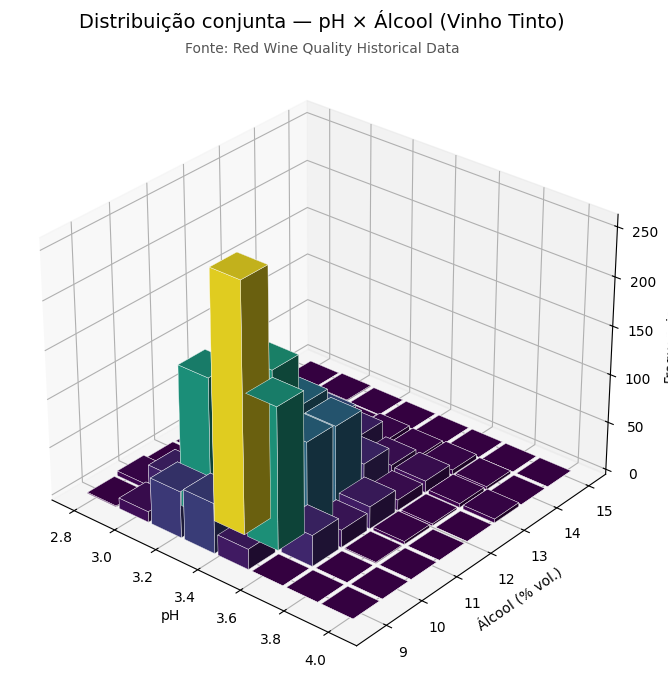

In [5]:
# histogram2d: conta quantos pontos (pH, álcool) caem em cada retângulo do plano.
# Retorna hist (grade de contagens), xedges e yedges (bordas dos bins em cada eixo).
hist, xedges, yedges = np.histogram2d(df["pH"], df["alcohol"], bins=(8, 8))

# Posição da base de cada barra no plano z=0: canto inferior esquerdo de cada célula do histograma.
# indexing="ij" alinha linhas com bins de pH e colunas com bins de álcool (como hist[i,j]).
# Os pequenos deslocamentos (+0.04, +0.25) centralizam visualmente as barras dentro dos bins (ajuste empírico).
xpos, ypos = np.meshgrid(xedges[:-1] + 0.04, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
# Todas as barras começam no "chão" z=0; a altura vem em dz.
zpos = np.zeros_like(xpos)

# Largura e profundidade das barras (ligeiramente < tamanho do bin) para aparecer um espaço entre elas.
dx = (xedges[1] - xedges[0]) * 0.9
dy = (yedges[1] - yedges[0]) * 0.9
# Altura = número de amostras naquele bin (achatamos hist para o mesmo vetor que xpos, ypos).
dz = hist.ravel()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Cor proporcional à contagem (normaliza pelo máximo para usar o colormap viridis).
colors = plt.cm.viridis(dz / dz.max())
# bar3d: para cada barra, (xpos,ypos,zpos) é um canto da caixa e (dx,dy,dz) são as dimensões.
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, edgecolor="white", linewidth=0.3)

ax.set_title("Distribuição conjunta — pH × Álcool (Vinho Tinto)", fontsize=14, pad=20)
ax.text2D(
    0.5,
    1,
    "Fonte: Red Wine Quality Historical Data",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_xlabel("pH")
ax.set_ylabel("Álcool (% vol.)")
ax.set_zlabel("Frequência")
ax.view_init(elev=30, azim=-50)

plt.tight_layout()
plt.savefig("bard3d.png", dpi=1000)
plt.show()